# Import + Chargement des données

In [19]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/eda_telco_churn.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,monthlycharges_group
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12 mois,Q1 - faible
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,0,25-48 mois,Q2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12 mois,Q2
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,25-48 mois,Q2
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12 mois,Q3


# Création de features métier

Dans le notebook précédent, nous avons pu observer que plus un client possède de service, plus il est attaché à son abonnement. Nous allons donc créer une variable stockant le nombre de services que le client possède.

In [20]:
services = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["num_services"] = df[services].apply(lambda x: (x == "Yes").sum(), axis=1)

Nous avons également pu observer que les clients les plus récents avaient tendance à s'en aller, nous allons donc créer une variable binaire expliquant si un client est nouveau ou non.

In [21]:
df["is_new_client"] = (df["tenure"] <= 12).astype(int)

Les clients étant fortement facturés avaient également un fort taux de churn, nous allons donc créer une variable expliquant si oui ou non un client possède une forte facturation en fonction de la médianne de celles-ci.

In [22]:
df["high_charges"] = (df["MonthlyCharges"] > df["MonthlyCharges"].median()).astype(int)

Nous allons également créer une variable facture par ancienneté afin de capturer la dépense moyenne cumulé d'un client.

In [23]:
df["charges_per_month"] = df["TotalCharges"] / (df["tenure"] + 1)

# Vérification des nouvelles features

In [24]:
df[[
    "num_services",
    "is_new_client",
    "high_charges",
    "charges_per_month"
]].describe()

,num_services,is_new_client,high_charges,charges_per_month
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,3.363339,0.309300,0.499573,59.083067
std,2.062067,0.462238,0.500035,30.514438
min,0.000000,0.000000,0.000000,9.183333
25%,1.000000,0.000000,0.000000,26.225944
50%,3.000000,0.000000,0.000000,61.070387
75%,5.000000,1.000000,1.000000,84.877538
max,8.000000,1.000000,1.000000,118.969863


# Séparer la cible et les variables explicatives

In [25]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Identifier les variables catégorielles et numériques

In [26]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group', 'monthlycharges_group']
Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'num_services', 'is_new_client', 'high_charges', 'charges_per_month']


# Encodage des variables catégorielles

Il est nécessaire d'encoder les variables catégorielles afin de pouvoir les utiliser dans des modèles prédictifs. Ceux-ci ne comprennent que les chiffres.

In [27]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

# Train / Test Split

Nous allons séparer la donnée en données d'entrainement en métant en place une stratégie sur y afin de garder la même proportion de churn dans le train et le test.

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
y_train.mean(), y_test.mean()

(np.float64(0.2657777777777778), np.float64(0.2658137882018479))

La distribution est correcte

# Pipeline

On va réaliser un pipeline complet comportant préprocessing et modèle

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=6000))
    ]
)

In [31]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

# Prédictions

In [32]:
y_pred = model.predict(X_test)

y_proba = model.predict_proba(X_test)[:,1]

# Evaluation du modèle

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



In [34]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_proba)

0.837391482158295

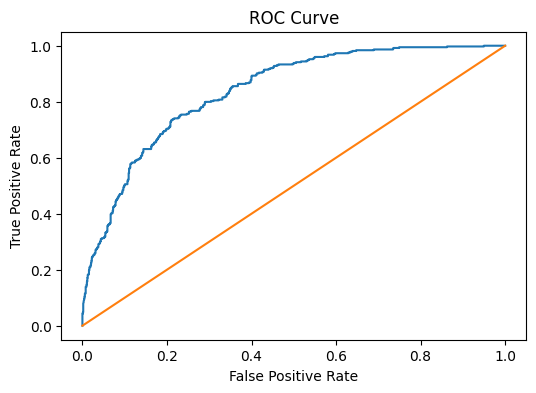

In [35]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

Nous obtenons un ROC de 0.84, ce qui est déjà une bonne baseline sur un premier modèle. Nous avons également développer une pipeline propre et du feature engineering.

In [36]:
df.to_csv("../data/processed/feature_engineered_telco_churn.csv", index=False)